Datensatz bereit: 6298 Zeilen, 164 Features

=== GESAMTERGEBNISSE: XGBOOST OHE-MODELL (BEIDE STRATEGIEN) ===
        Strategie 1: Holdout (60:20:20) Strategie 2: CV auf 80 % Train (Mittelwert ± Std)  Strategie 2: Holdout (80:20)
Metrik                                                                                                                 
R²                               0.3260                                 0.3549 (± 0.0310)                        0.3205
MAE                              0.1382                                 0.1366 (± 0.0075)                        0.1380

--- CV Einzelergebnisse je Fold (Strategie 2: 80 % Trainingsdaten) ---
R² pro Fold:  [0.3072, 0.4036, 0.3463, 0.3637, 0.3536]
MAE pro Fold: [0.1494, 0.1312, 0.1335, 0.1405, 0.1284]

=== TOP 15 FEATURE IMPORTANCE (FINALER XGBOOST-REGRESSOR) ===
                                    Feature Importance Importance_Prozent
                               is_superhost    0.12318             12.32%
                  

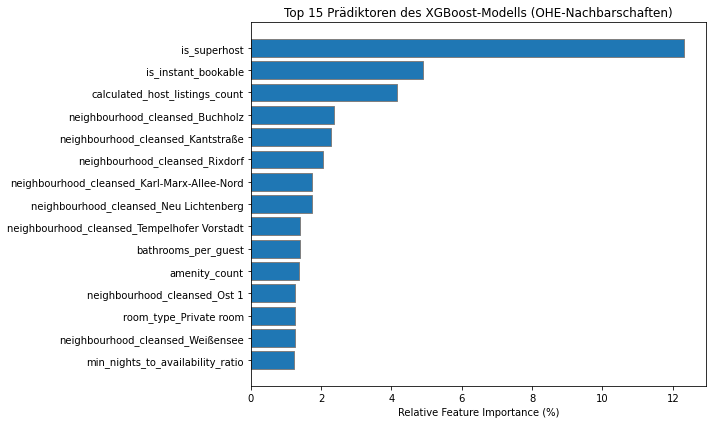

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from xgboost import XGBRegressor

# ==============================================================================
# 1. DATENSATZ LADEN & BEREINIGEN
# ==============================================================================
df_ohe = pd.read_pickle("df_model_neighbourhood_ohe.pkl")

# Zielvariable isolieren
y = df_ohe["review_scores_rating"]

# Leakage-, Text- und redundante Spalten entfernen
drop_cols = ["review_scores_rating"]
for c in [
    "review_scores_location",
    "review_neighbourhood_rating",
    "neighbourhood_cleansed",
]:
    if c in df_ohe.columns:
        drop_cols.append(c)

X_ohe = df_ohe.drop(columns=drop_cols)

print(f"Datensatz bereit: {X_ohe.shape[0]} Zeilen, {X_ohe.shape[1]} Features\n")

# ==============================================================================
# 2. HYPERPARAMETER LAUT METHODENKAPITEL
# ==============================================================================
xgb_params = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
}

# ==============================================================================
# 3. STRATEGIE 1: BASIS-EVALUATION (60:20:20-SPLIT)
# ==============================================================================
# Erster Split: 80 % Temp (Train + Val) und 20 % Test
X_temp, X_test_60, y_temp, y_test_60 = train_test_split(
    X_ohe, y, test_size=0.20, random_state=42
)

# Zweiter Split: Temp in 60 % Train und 20 % Val
X_train_60, X_val_60, y_train_60, y_val_60 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

model_60 = XGBRegressor(**xgb_params)
model_60.fit(X_train_60, y_train_60, eval_set=[(X_val_60, y_val_60)], verbose=False)

preds_test_60 = model_60.predict(X_test_60)
r2_60 = r2_score(y_test_60, preds_test_60)
mae_60 = mean_absolute_error(y_test_60, preds_test_60)

# ==============================================================================
# 4. STRATEGIE 2: 80:20-SPLIT MIT 5-FOLD CV INNERHALB DER TRAININGSDATEN
# ==============================================================================
# 80 % Trainingsdaten (für CV & finales Training), 20 % Holdout-Testset
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_ohe, y, test_size=0.20, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_out = cross_validate(
    XGBRegressor(**xgb_params),
    X_train_80,
    y_train_80,
    cv=kf,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
    n_jobs=-1,
)

cv_r2_scores = cv_out["test_r2"]
cv_mae_scores = -cv_out["test_mae"]

# Finales Modell der 80:20-Strategie auf den gesamten 80 % Trainingsdaten fitten
final_model_80 = XGBRegressor(**xgb_params)
final_model_80.fit(X_train_80, y_train_80)

preds_test_80 = final_model_80.predict(X_test_80)
r2_80 = r2_score(y_test_80, preds_test_80)
mae_80 = mean_absolute_error(y_test_80, preds_test_80)

# ==============================================================================
# 5. ERGEBNISVERGLEICH BEIDER STRATEGIEN AUSGEBEN
# ==============================================================================
comparison_table = pd.DataFrame(
    {
        "Metrik": ["R²", "MAE"],
        "Strategie 1: Holdout (60:20:20)": [round(r2_60, 4), round(mae_60, 4)],
        "Strategie 2: CV auf 80 % Train (Mittelwert ± Std)": [
            f"{cv_r2_scores.mean():.4f} (± {cv_r2_scores.std():.4f})",
            f"{cv_mae_scores.mean():.4f} (± {cv_mae_scores.std():.4f})",
        ],
        "Strategie 2: Holdout (80:20)": [round(r2_80, 4), round(mae_80, 4)],
    }
).set_index("Metrik")

print("=" * 80)
print("=== GESAMTERGEBNISSE: XGBOOST OHE-MODELL (BEIDE STRATEGIEN) ===")
print("=" * 80)
print(comparison_table.to_string())

print("\n--- CV Einzelergebnisse je Fold (Strategie 2: 80 % Trainingsdaten) ---")
print(f"R² pro Fold:  {[round(x, 4) for x in cv_r2_scores]}")
print(f"MAE pro Fold: {[round(x, 4) for x in cv_mae_scores]}")

# ==============================================================================
# 6. TOP 15 FEATURE IMPORTANCE (BASIS: FINALER REGRESSOR AUS STRATEGIE 2)
# ==============================================================================
importance_df = pd.DataFrame(
    {"Feature": X_train_80.columns, "Importance": final_model_80.feature_importances_}
).sort_values(by="Importance", ascending=False)

importance_df["Importance_Prozent"] = (
    importance_df["Importance"] / importance_df["Importance"].sum()
) * 100

print("\n" + "=" * 80)
print("=== TOP 15 FEATURE IMPORTANCE (FINALER XGBOOST-REGRESSOR) ===")
print("=" * 80)
print(
    importance_df.head(15).to_string(
        index=False,
        formatters={
            "Importance": "{:.5f}".format,
            "Importance_Prozent": "{:.2f}%".format,
        },
    )
)

# ==============================================================================
# 7. VISUALISIERUNG DER TOP 15 FEATURES
# ==============================================================================
top15 = importance_df.head(15).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top15["Feature"],
    top15["Importance_Prozent"],
    color="#1f77b4",
    edgecolor="gray",
)
plt.xlabel("Relative Feature Importance (%)")
plt.title("Top 15 Prädiktoren des XGBoost-Modells (OHE-Nachbarschaften)")
plt.tight_layout()
plt.show()

In [9]:
# ==============================================================================
# ZUSATZ: BERECHNUNG DES ADJUSTIERTEN R² FÜR ALLE EVALUATIONSPFADE
# ==============================================================================
def calculate_adjusted_r2(r2, n, p):
    """Berechnet das adjustierte R² (n = Stichprobengröße, p = Anzahl Features)."""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


p_features = X_ohe.shape[1]

# 1. Strategie 1: Holdout-Testset (60:20:20 Split)
n_test_60 = len(y_test_60)
adj_r2_60 = calculate_adjusted_r2(r2_60, n_test_60, p_features)

# 2. Strategie 2: Folds der 5-Fold Cross-Validation (je Fold: 80% von 80% Trainingsdaten)
# In 5-Fold CV auf 80% Train hat jeder Test-Fold: n_val_fold = len(y_train_80) / 5
n_val_fold = int(np.ceil(len(y_train_80) / 5))
cv_adj_r2_scores = [
    calculate_adjusted_r2(score, n_val_fold, p_features) for score in cv_r2_scores
]

# 3. Strategie 2: Holdout-Testset (80:20 Split)
n_test_80 = len(y_test_80)
adj_r2_80 = calculate_adjusted_r2(r2_80, n_test_80, p_features)

# ==============================================================================
# ERWEITERTE VERGLEICHSTABELLE AUSGEBEN
# ==============================================================================
extended_comparison_table = pd.DataFrame(
    {
        "Metrik": ["R²", "Adjusted R²", "MAE"],
        "Strategie 1: Holdout (60:20:20)": [
            f"{r2_60:.4f}",
            f"{adj_r2_60:.4f}",
            f"{mae_60:.4f}",
        ],
        "Strategie 2: CV auf 80 % Train (Mittelwert ± Std)": [
            f"{cv_r2_scores.mean():.4f} (± {cv_r2_scores.std():.4f})",
            f"{np.mean(cv_adj_r2_scores):.4f} (± {np.std(cv_adj_r2_scores):.4f})",
            f"{cv_mae_scores.mean():.4f} (± {cv_mae_scores.std():.4f})",
        ],
        "Strategie 2: Holdout (80:20)": [
            f"{r2_80:.4f}",
            f"{adj_r2_80:.4f}",
            f"{mae_80:.4f}",
        ],
    }
).set_index("Metrik")

print("\n" + "=" * 90)
print(
    f"=== METRIKEN INKL. ADJUSTIERTEM R² (p = {p_features} Features, Gesamt N = {len(df_ohe)}) ==="
)
print("=" * 90)
print(extended_comparison_table.to_string())
print("-" * 90)
print(f"Stichprobengrößen der Testsets:")
print(f"  - Holdout Testset (Strategie 1 & 2): n = {n_test_60}")
print(f"  - Validierungs-Fold (Strategie 2 CV): n ≈ {n_val_fold}")
print("=" * 90)


=== METRIKEN INKL. ADJUSTIERTEM R² (p = 164 Features, Gesamt N = 6298) ===
            Strategie 1: Holdout (60:20:20) Strategie 2: CV auf 80 % Train (Mittelwert ± Std) Strategie 2: Holdout (80:20)
Metrik                                                                                                                    
R²                                   0.3260                                 0.3549 (± 0.0310)                       0.3205
Adjusted R²                          0.2250                                 0.2294 (± 0.0370)                       0.2187
MAE                                  0.1382                                 0.1366 (± 0.0075)                       0.1380
------------------------------------------------------------------------------------------
Stichprobengrößen der Testsets:
  - Holdout Testset (Strategie 1 & 2): n = 1260
  - Validierungs-Fold (Strategie 2 CV): n ≈ 1008


Datensatz bereit: 6298 Zeilen, 30 Features

=== GESAMTERGEBNISSE: XGBOOST TARGET-ENCODING (p = 30, N = 6298) ===
            Strategie 1: Holdout (60:20:20) Strategie 2: CV auf 80 % Train (Mittelwert ± Std) Strategie 2: Holdout (80:20)
Metrik                                                                                                                    
R²                                   0.2860                                 0.3437 (± 0.0400)                       0.2980
Adjusted R²                          0.2686                                 0.3236 (± 0.0413)                       0.2809
MAE                                  0.1417                                 0.1365 (± 0.0075)                       0.1402
------------------------------------------------------------------------------------------
R² pro CV-Fold:       [0.3139, 0.4053, 0.3486, 0.3618, 0.2892]
Adj. R² pro CV-Fold:  [0.2928, 0.387, 0.3286, 0.3422, 0.2673]
MAE pro CV-Fold:      [0.1497, 0.1289, 0.1324, 0.1399, 0

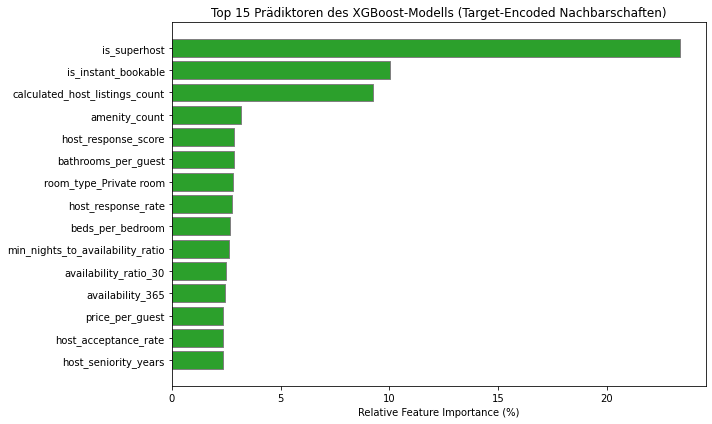

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from xgboost import XGBRegressor


# ==============================================================================
# HILFSFUNKTION: ADJUSTIERTES R²
# ==============================================================================
def calculate_adjusted_r2(r2, n, p):
    """Berechnet das adjustierte R² (n = Stichprobengröße, p = Anzahl Features)."""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


# ==============================================================================
# 1. DATENSATZ LADEN & BEREINIGEN (TARGET ENCODING)
# ==============================================================================
try:
    df_target = df_model_target_encoded.copy()
except NameError:
    df_target = pd.read_pickle("df_model_target_encoded.pkl")

# Zielvariable isolieren
y = df_target["review_scores_rating"]

# Leakage-, Text- und redundante Spalten entfernen
drop_cols = ["review_scores_rating"]
for c in [
    "review_scores_location",
    "review_neighbourhood_rating",
    "neighbourhood_cleansed",
]:
    if c in df_target.columns:
        drop_cols.append(c)

X_target = df_target.drop(columns=drop_cols)
p_features = X_target.shape[1]

print(f"Datensatz bereit: {X_target.shape[0]} Zeilen, {p_features} Features\n")

# ==============================================================================
# 2. HYPERPARAMETER LAUT METHODENKAPITEL
# ==============================================================================
xgb_params = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
}

# ==============================================================================
# 3. STRATEGIE 1: BASIS-EVALUATION (60:20:20-SPLIT)
# ==============================================================================
X_temp, X_test_60, y_temp, y_test_60 = train_test_split(
    X_target, y, test_size=0.20, random_state=42
)
X_train_60, X_val_60, y_train_60, y_val_60 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

model_60 = XGBRegressor(**xgb_params)
model_60.fit(X_train_60, y_train_60, eval_set=[(X_val_60, y_val_60)], verbose=False)

preds_test_60 = model_60.predict(X_test_60)
r2_60 = r2_score(y_test_60, preds_test_60)
mae_60 = mean_absolute_error(y_test_60, preds_test_60)
adj_r2_60 = calculate_adjusted_r2(r2_60, len(y_test_60), p_features)

# ==============================================================================
# 4. STRATEGIE 2: 80:20-SPLIT MIT 5-FOLD CV INNERHALB DER TRAININGSDATEN
# ==============================================================================
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_target, y, test_size=0.20, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_out = cross_validate(
    XGBRegressor(**xgb_params),
    X_train_80,
    y_train_80,
    cv=kf,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
    n_jobs=-1,
)

cv_r2_scores = cv_out["test_r2"]
cv_mae_scores = -cv_out["test_mae"]

n_val_fold = int(np.ceil(len(y_train_80) / 5))
cv_adj_r2_scores = [
    calculate_adjusted_r2(score, n_val_fold, p_features) for score in cv_r2_scores
]

# Finales Modell auf den gesamten 80 % Trainingsdaten fitten
final_model_80 = XGBRegressor(**xgb_params)
final_model_80.fit(X_train_80, y_train_80)

preds_test_80 = final_model_80.predict(X_test_80)
r2_80 = r2_score(y_test_80, preds_test_80)
mae_80 = mean_absolute_error(y_test_80, preds_test_80)
adj_r2_80 = calculate_adjusted_r2(r2_80, len(y_test_80), p_features)

# ==============================================================================
# 5. ERGEBNISVERGLEICH BEIDER STRATEGIEN AUSGEBEN (INKL. ADJ. R²)
# ==============================================================================
comparison_table = pd.DataFrame(
    {
        "Metrik": ["R²", "Adjusted R²", "MAE"],
        "Strategie 1: Holdout (60:20:20)": [
            f"{r2_60:.4f}",
            f"{adj_r2_60:.4f}",
            f"{mae_60:.4f}",
        ],
        "Strategie 2: CV auf 80 % Train (Mittelwert ± Std)": [
            f"{cv_r2_scores.mean():.4f} (± {cv_r2_scores.std():.4f})",
            f"{np.mean(cv_adj_r2_scores):.4f} (± {np.std(cv_adj_r2_scores):.4f})",
            f"{cv_mae_scores.mean():.4f} (± {cv_mae_scores.std():.4f})",
        ],
        "Strategie 2: Holdout (80:20)": [
            f"{r2_80:.4f}",
            f"{adj_r2_80:.4f}",
            f"{mae_80:.4f}",
        ],
    }
).set_index("Metrik")

print("=" * 90)
print(
    f"=== GESAMTERGEBNISSE: XGBOOST TARGET-ENCODING (p = {p_features}, N = {len(df_target)}) ==="
)
print("=" * 90)
print(comparison_table.to_string())
print("-" * 90)
print(f"R² pro CV-Fold:       {[round(x, 4) for x in cv_r2_scores]}")
print(f"Adj. R² pro CV-Fold:  {[round(x, 4) for x in cv_adj_r2_scores]}")
print(f"MAE pro CV-Fold:      {[round(x, 4) for x in cv_mae_scores]}")
print("=" * 90)

# ==============================================================================
# 6. TOP 15 FEATURE IMPORTANCE (BASIS: FINALER REGRESSOR AUS STRATEGIE 2)
# ==============================================================================
importance_df = pd.DataFrame(
    {"Feature": X_train_80.columns, "Importance": final_model_80.feature_importances_}
).sort_values(by="Importance", ascending=False)

importance_df["Importance_Prozent"] = (
    importance_df["Importance"] / importance_df["Importance"].sum()
) * 100

print("\n" + "=" * 90)
print("=== TOP 15 FEATURE IMPORTANCE (TARGET-ENCODED MODELL) ===")
print("=" * 90)
print(
    importance_df.head(15).to_string(
        index=False,
        formatters={
            "Importance": "{:.5f}".format,
            "Importance_Prozent": "{:.2f}%".format,
        },
    )
)

# ==============================================================================
# 7. VISUALISIERUNG DER TOP 15 FEATURES
# ==============================================================================
top15 = importance_df.head(15).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top15["Feature"],
    top15["Importance_Prozent"],
    color="#2ca02c",
    edgecolor="gray",
)
plt.xlabel("Relative Feature Importance (%)")
plt.title("Top 15 Prädiktoren des XGBoost-Modells (Target-Encoded Nachbarschaften)")
plt.tight_layout()
plt.show()